# Análisis de Estrategias de Fusión - HybridRank RAG

Este notebook analiza los resultados de la evaluación comparativa
de diferentes estrategias de fusión para el sistema HybridRank RAG.

**Prerequisito**: Ejecutar `experiments/evaluate_fusion_strategies.py` para generar los datos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

RESULTS_DIR = Path('../experiments/results')
df = pd.read_csv(RESULTS_DIR / 'fusion_metrics.csv')

METRIC_COLS = ['recall', 'precision', 'f1', 'mrr', 'map', 'ndcg']
BASELINES = ['bm25_only', 'dense_only']
FUSION_STRATEGIES = [s for s in df['strategy'].unique() if s not in BASELINES and 'hybridrank' not in s]
HR_STRATEGIES = [s for s in df['strategy'].unique() if 'hybridrank' in s]

print(f'Total filas: {len(df)}')
print(f'Estrategias: {df["strategy"].nunique()} ({len(BASELINES)} baselines, {len(FUSION_STRATEGIES)} fusion, {len(HR_STRATEGIES)} hybridrank)')
print(f'Queries: {df["query_id"].nunique()}')
print(f'Valores de k: {sorted(df["top_k"].unique())}')
print(f'NaN totales: {df[METRIC_COLS].isnull().sum().sum()}')
df.head()

Total filas: 960
Estrategias: 16 (2 baselines, 9 fusion, 5 hybridrank)
Queries: 20
Valores de k: [5, 10, 20]
NaN totales: 0


,top_k,recall,precision,f1,mrr,map,ndcg,strategy,query_id,query_type,retriever_name
0,5,0.384615,1.0,0.555556,1.0,0.384615,1.000000,bm25_only,q1,referencia_exacta,bm25_only
1,10,0.769231,1.0,0.869565,1.0,0.769231,1.000000,bm25_only,q1,referencia_exacta,bm25_only
2,20,0.923077,0.6,0.727273,1.0,0.923077,0.950956,bm25_only,q1,referencia_exacta,bm25_only
3,5,0.666667,0.8,0.727273,1.0,0.536111,0.786014,bm25_only,q2,referencia_exacta,bm25_only
4,10,1.000000,0.6,0.750000,1.0,0.786111,0.900172,bm25_only,q2,referencia_exacta,bm25_only


## 1. Vista General: Tabla Agregada por Estrategia

In [2]:
# Resumen por estrategia (promedio sobre todas las queries y k_values)
summary = df.groupby('strategy')[METRIC_COLS].mean().round(4)
summary = summary.sort_values('ndcg', ascending=False)
summary.style.background_gradient(cmap='RdYlGn', axis=0)

,recall,precision,f1,mrr,map,ndcg
strategy,,,,,,
combsum_zscore,0.694900,0.620000,0.567700,0.941700,0.593400,0.838700
combsum_minmax,0.678700,0.608300,0.555900,0.950000,0.583300,0.830600
weighted_a0.5,0.678700,0.608300,0.555900,0.950000,0.583300,0.830600
weighted_a0.3,0.649000,0.595800,0.538500,0.916700,0.555100,0.804400
weighted_a0.7,0.673200,0.575800,0.536900,0.929800,0.558100,0.799300
hybridrank_a0.7_b0.3,0.668300,0.567500,0.532000,0.935000,0.548800,0.793700
bm25_only,0.639500,0.559200,0.512900,0.929800,0.536200,0.778700
combmnz_minmax,0.646800,0.554200,0.520000,0.925000,0.537300,0.775000
hybridrank_a0.5_b0.5,0.647400,0.543300,0.513300,0.925000,0.532000,0.766600


## 2. Baselines vs Estrategias de Fusion (k=10)

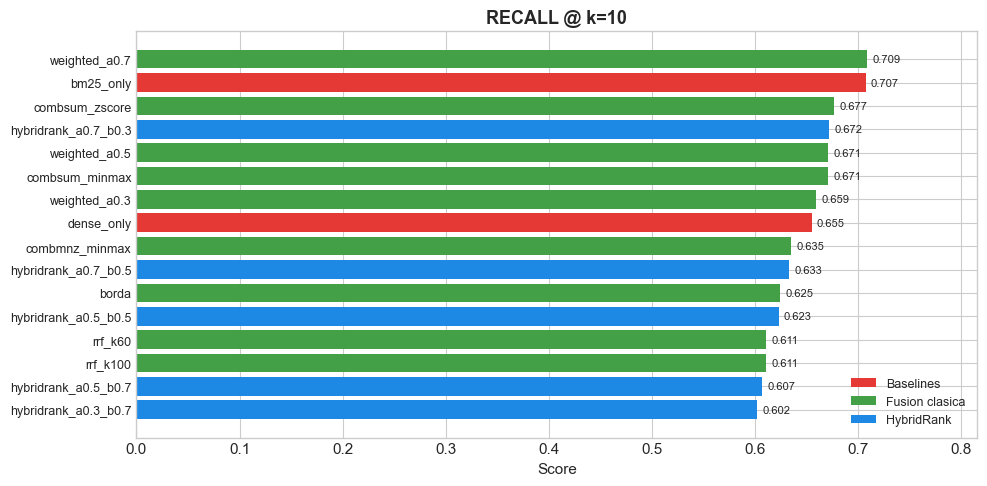

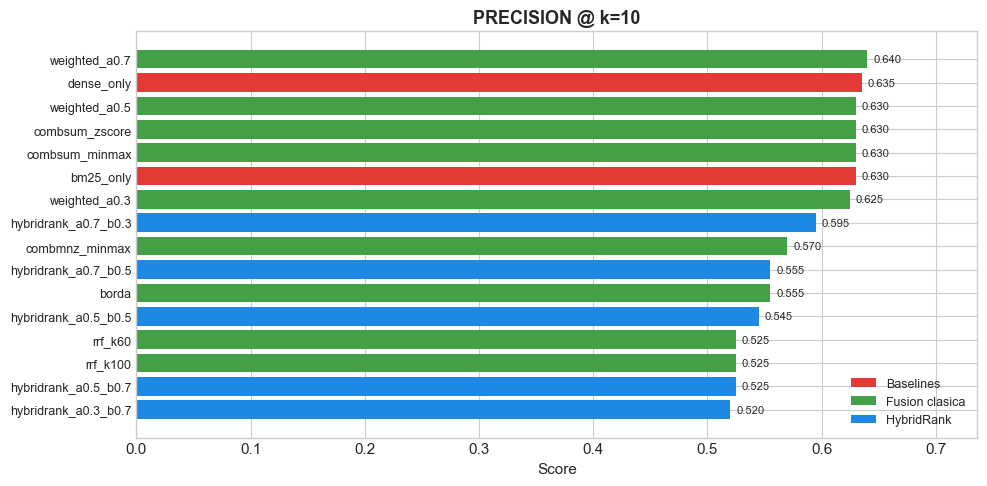

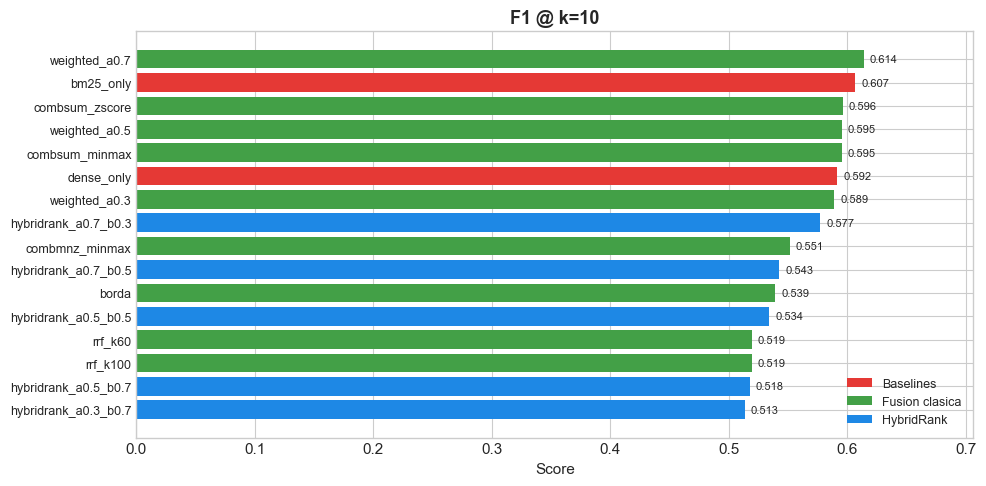

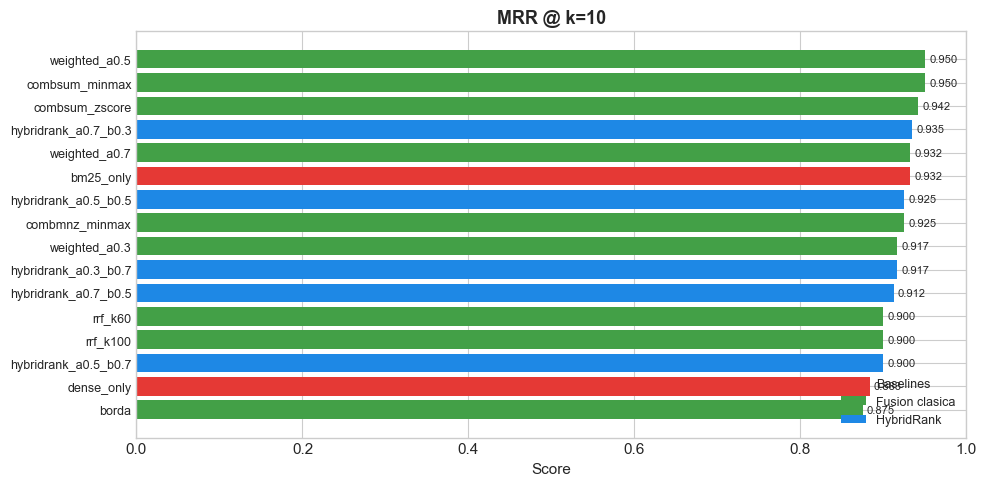

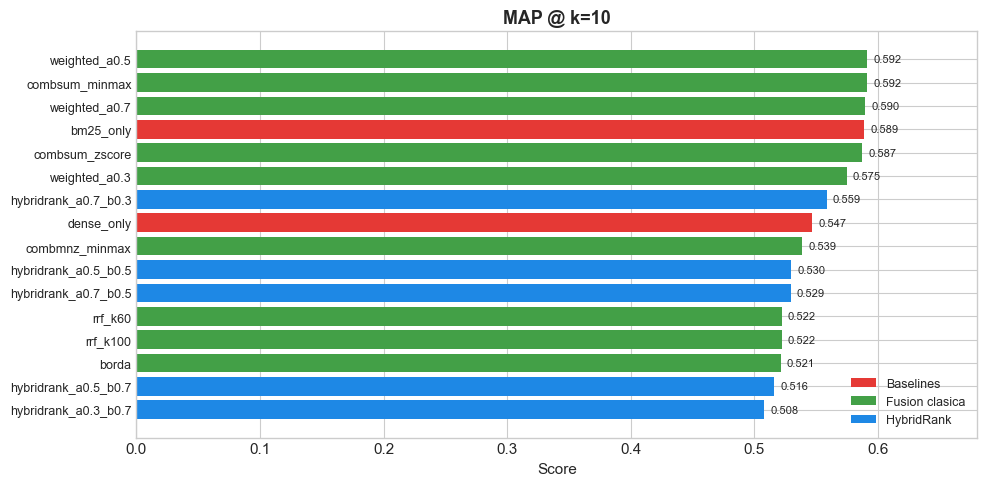

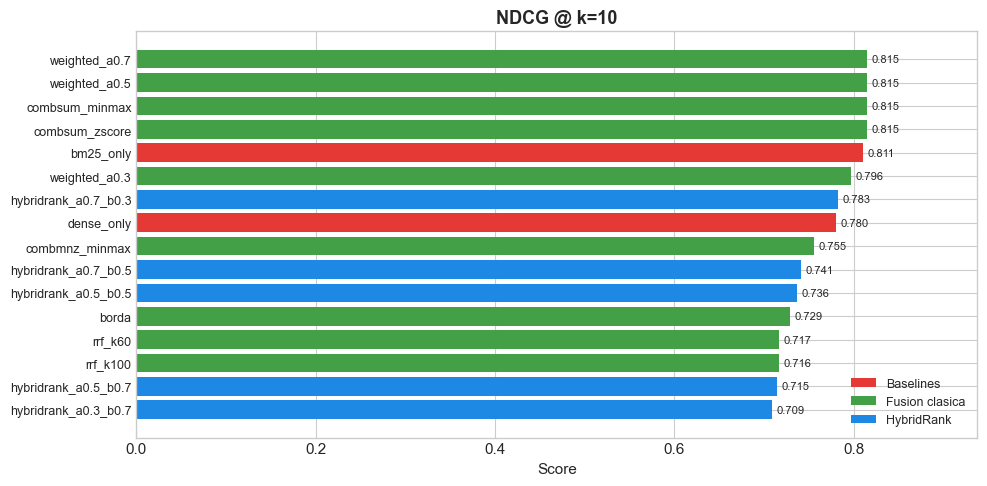

In [3]:
# Comparacion individual por metrica - graficos separados y claros
df_k10 = df[df['top_k'] == 10].copy()
summary_k10 = df_k10.groupby('strategy')[METRIC_COLS].mean()

for metric in METRIC_COLS:
    fig, ax = plt.subplots(figsize=(10, 5))
    data = summary_k10[metric].sort_values(ascending=True)
    
    colors = []
    for name in data.index:
        if name in BASELINES:
            colors.append('#E53935')
        elif 'hybridrank' in name:
            colors.append('#1E88E5')
        else:
            colors.append('#43A047')
    
    bars = ax.barh(range(len(data)), data.values, color=colors)
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data.index, fontsize=9)
    ax.set_xlabel('Score')
    ax.set_title(f'{metric.upper()} @ k=10', fontsize=13, fontweight='bold')
    ax.set_xlim(0, min(1.0, data.max() * 1.15))
    
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#E53935', label='Baselines'),
        Patch(facecolor='#43A047', label='Fusion clasica'),
        Patch(facecolor='#1E88E5', label='HybridRank'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'{metric}_k10.png', dpi=150, bbox_inches='tight')
    plt.show()

In [4]:
# Tabla comparativa: todas las estrategias agrupadas por familia (k=10)
df_k10 = df[df['top_k'] == 10].copy()
summary_k10 = df_k10.groupby('strategy')[METRIC_COLS].mean().round(4)

# Calcular métrica Objective
summary_k10['objective'] = (
    0.4 * summary_k10['ndcg'] +
    0.3 * summary_k10['recall'] +
    0.2 * summary_k10['map'] +
    0.1 * summary_k10['f1']
).round(4)

# Asignar familia a cada estrategia
def get_family(strategy):
    if strategy in BASELINES:
        return 'Baseline'
    elif 'hybridrank' in strategy:
        return 'HybridRank'
    else:
        return 'Fusión Clásica'

summary_k10['Familia'] = summary_k10.index.map(get_family)

# Orden por familia: Baseline primero, luego Fusión Clásica, luego HybridRank
family_order = {'Baseline': 0, 'Fusión Clásica': 1, 'HybridRank': 2}
summary_k10['_order'] = summary_k10['Familia'].map(family_order)
summary_k10 = summary_k10.sort_values(['_order', 'ndcg'], ascending=[True, False])
summary_k10 = summary_k10.drop(columns=['_order'])

# Reorganizar columnas: Familia primero, luego métricas y objective
cols = ['Familia'] + METRIC_COLS + ['objective']
summary_k10 = summary_k10[cols]

# Identificar el mejor valor por métrica (global)
best_per_metric = {m: summary_k10[m].max() for m in METRIC_COLS + ['objective']}

def highlight_best(val, metric):
    if val == best_per_metric[metric]:
        return 'font-weight: bold'
    return ''

styled = summary_k10.style.apply(
    lambda col: [highlight_best(v, col.name) if col.name in METRIC_COLS + ['objective'] else '' for v in col],
    axis=0
)

print('Comparativa de estrategias por familia (k=10):')
print('(Mejor valor por métrica en negrita)')
print('Objective = 0.4*nDCG + 0.3*Recall + 0.2*MAP + 0.1*F1\n')
styled

Comparativa de estrategias por familia (k=10):
(Mejor valor por métrica en negrita)
Objective = 0.4*nDCG + 0.3*Recall + 0.2*MAP + 0.1*F1



,Familia,recall,precision,f1,mrr,map,ndcg,objective
strategy,,,,,,,,
bm25_only,Baseline,0.707200,0.630000,0.606700,0.932100,0.588700,0.810700,0.714800
dense_only,Baseline,0.655100,0.635000,0.591700,0.883300,0.547000,0.779800,0.677000
weighted_a0.7,Fusión Clásica,0.709000,0.640000,0.613900,0.932100,0.589800,0.815200,0.718100
combsum_minmax,Fusión Clásica,0.670800,0.630000,0.595400,0.950000,0.591600,0.815100,0.705100
weighted_a0.5,Fusión Clásica,0.670800,0.630000,0.595400,0.950000,0.591600,0.815100,0.705100
combsum_zscore,Fusión Clásica,0.676600,0.630000,0.596400,0.941700,0.587200,0.814800,0.706000
weighted_a0.3,Fusión Clásica,0.659100,0.625000,0.588800,0.916700,0.574900,0.796500,0.690200
combmnz_minmax,Fusión Clásica,0.635200,0.570000,0.551300,0.925000,0.538700,0.755200,0.655500
borda,Fusión Clásica,0.624700,0.555000,0.539100,0.875000,0.521400,0.728600,0.637000


## 3. Efecto de k en las Metricas (por grupo de estrategia)

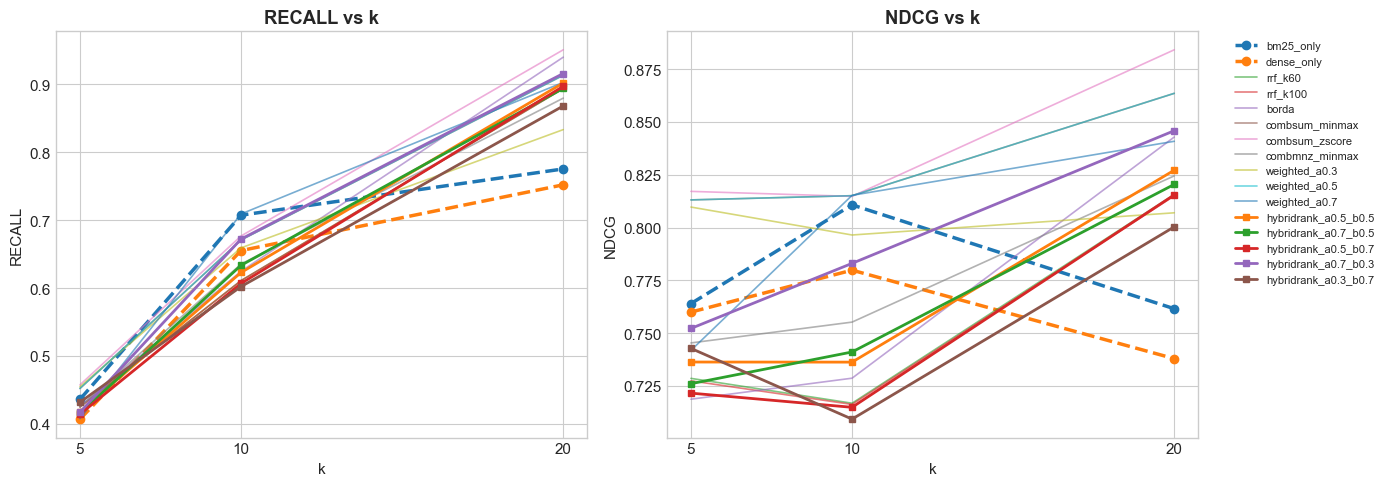

In [5]:
# Lineas: como cambian recall y ndcg al variar k
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ['recall', 'ndcg']):
    for strategy in df['strategy'].unique():
        df_s = df[df['strategy'] == strategy].groupby('top_k')[metric].mean()
        
        if strategy in BASELINES:
            style = {'linewidth': 2.5, 'linestyle': '--', 'marker': 'o'}
        elif 'hybridrank' in strategy:
            style = {'linewidth': 2, 'linestyle': '-', 'marker': 's', 'markersize': 5}
        else:
            style = {'linewidth': 1.2, 'linestyle': '-', 'alpha': 0.6}
        
        ax.plot(df_s.index, df_s.values, label=strategy, **style)
    
    ax.set_xlabel('k')
    ax.set_ylabel(metric.upper())
    ax.set_title(f'{metric.upper()} vs k', fontweight='bold')
    ax.set_xticks(sorted(df['top_k'].unique()))

axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'metrics_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Analisis por Tipo de Query

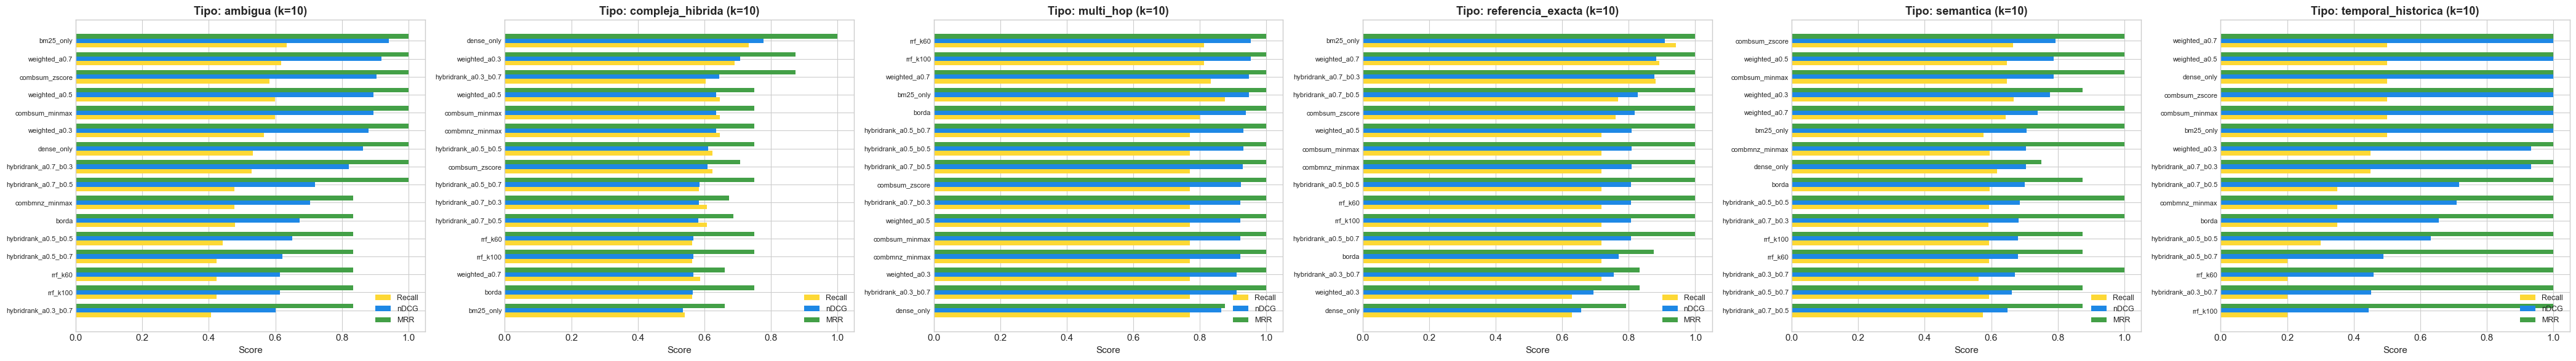

In [6]:
# Rendimiento por tipo de query (k=10)
if 'query_type' in df.columns and df['query_type'].nunique() > 1:
    query_types = sorted(df['query_type'].unique())
    
    fig, axes = plt.subplots(1, len(query_types), figsize=(7 * len(query_types), 6))
    if len(query_types) == 1:
        axes = [axes]
    
    for ax, qt in zip(axes, query_types):
        df_qt = df[(df['query_type'] == qt) & (df['top_k'] == 10)]
        data = df_qt.groupby('strategy')[['recall', 'ndcg', 'mrr']].mean().sort_values('ndcg')
        
        x = np.arange(len(data))
        width = 0.25
        
        ax.barh(x - width, data['recall'], width, label='Recall', color='#FDD835')
        ax.barh(x, data['ndcg'], width, label='nDCG', color='#1E88E5')
        ax.barh(x + width, data['mrr'], width, label='MRR', color='#43A047')
        
        ax.set_yticks(x)
        ax.set_yticklabels(data.index, fontsize=8)
        ax.set_xlabel('Score')
        ax.set_title(f'Tipo: {qt} (k=10)', fontweight='bold')
        ax.legend(fontsize=9)
        ax.set_xlim(0, 1.05)
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'by_query_type.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Solo hay un tipo de query o falta la columna query_type')

## 5. Heatmap: Variantes HybridRank (k=10)

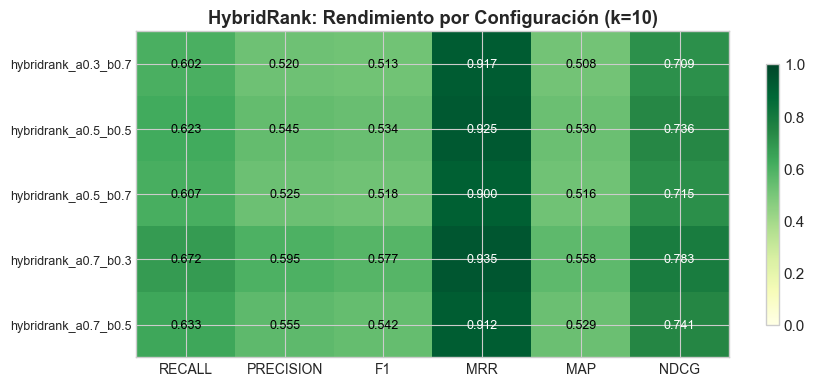

In [7]:
# Heatmap solo de variantes HybridRank
if HR_STRATEGIES:
    df_hr = df[df['strategy'].isin(HR_STRATEGIES) & (df['top_k'] == 10)]
    hr_summary = df_hr.groupby('strategy')[METRIC_COLS].mean().round(4)
    
    fig, ax = plt.subplots(figsize=(9, 4))
    im = ax.imshow(hr_summary.values, cmap='YlGn', aspect='auto', vmin=0, vmax=1)
    
    ax.set_xticks(range(len(hr_summary.columns)))
    ax.set_xticklabels([c.upper() for c in hr_summary.columns], fontsize=10)
    ax.set_yticks(range(len(hr_summary.index)))
    ax.set_yticklabels(hr_summary.index, fontsize=9)
    
    for i in range(len(hr_summary.index)):
        for j in range(len(hr_summary.columns)):
            val = hr_summary.values[i, j]
            color = 'white' if val > 0.7 else 'black'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9, color=color)
    
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title('HybridRank: Rendimiento por Configuración (k=10)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'hybridrank_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No se encontraron estrategias HybridRank')

## 6. Mejora Porcentual sobre Baselines

In [8]:
# Mejora porcentual sobre el mejor baseline (k=10)
strategy_means = df_k10.groupby('strategy')[METRIC_COLS].mean()
baseline_means = strategy_means.loc[strategy_means.index.isin(BASELINES)]
best_baseline = baseline_means.max()

# Evitar division por cero
best_baseline_safe = best_baseline.replace(0, np.nan)
improvement = ((strategy_means - best_baseline) / best_baseline_safe * 100).round(2)
improvement = improvement.loc[~improvement.index.isin(BASELINES)]

print('Mejora porcentual sobre mejor baseline (k=10):')
print('(Positivo = supera al mejor baseline)\n')
improvement.style.applymap(
    lambda v: 'color: green; font-weight: bold' if isinstance(v, (int, float)) and v > 0 
    else ('color: red' if isinstance(v, (int, float)) and v < 0 else '')
)

Mejora porcentual sobre mejor baseline (k=10):
(Positivo = supera al mejor baseline)



C:\Users\javie\AppData\Local\Temp\ipykernel_174264\1090384630.py:13: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  improvement.style.applymap(


,recall,precision,f1,mrr,map,ndcg
strategy,,,,,,
borda,-11.680000,-12.600000,-11.150000,-6.130000,-11.440000,-10.130000
combmnz_minmax,-10.180000,-10.240000,-9.140000,-0.770000,-8.500000,-6.850000
combsum_minmax,-5.160000,-0.790000,-1.860000,1.920000,0.480000,0.540000
combsum_zscore,-4.330000,-0.790000,-1.710000,1.020000,-0.250000,0.490000
hybridrank_a0.3_b0.7,-14.860000,-18.110000,-15.410000,-1.660000,-13.690000,-12.520000
hybridrank_a0.5_b0.5,-11.930000,-14.170000,-11.980000,-0.770000,-10.000000,-9.190000
hybridrank_a0.5_b0.7,-14.210000,-17.320000,-14.700000,-3.450000,-12.320000,-11.830000
hybridrank_a0.7_b0.3,-4.970000,-6.300000,-4.860000,0.310000,-5.130000,-3.420000
hybridrank_a0.7_b0.5,-10.430000,-12.600000,-10.580000,-2.110000,-10.090000,-8.600000


## 7. Tabla Detallada por Tipo de Query (k=10)

Complementa la sección 4 con valores numéricos exactos.
Muestra el rendimiento de cada estrategia desglosado por `query_type` para identificar
en qué tipos de consulta cada estrategia es más fuerte o más débil.

In [9]:
# Pivot: estrategia x query_type para métricas clave (k=10)
df_k10 = df[df['top_k'] == 10].copy()
key_metrics = ['recall', 'ndcg', 'mrr']

for metric in key_metrics:
    pivot = df_k10.pivot_table(
        values=metric, index='strategy', columns='query_type', aggfunc='mean'
    ).round(4)
    
    pivot['PROMEDIO'] = pivot.mean(axis=1)
    pivot = pivot.sort_values('PROMEDIO', ascending=False)
    
    print(f'\n{"="*60}')
    print(f'  {metric.upper()} por Tipo de Query (k=10)')
    print(f'{"="*60}')
    display(pivot.style.background_gradient(cmap='RdYlGn', axis=None, vmin=0, vmax=1))


  RECALL por Tipo de Query (k=10)


query_type,ambigua,compleja_hibrida,multi_hop,referencia_exacta,semantica,temporal_historica,PROMEDIO
strategy,,,,,,,
weighted_a0.7,0.616700,0.587500,0.833300,0.892300,0.644300,0.500000,0.679017
bm25_only,0.633300,0.541700,0.875000,0.942300,0.577200,0.500000,0.678250
combsum_zscore,0.581500,0.625000,0.770800,0.760600,0.665500,0.500000,0.650567
combsum_minmax,0.598100,0.645800,0.770800,0.717300,0.646200,0.500000,0.646367
weighted_a0.5,0.598100,0.645800,0.770800,0.717300,0.646200,0.500000,0.646367
hybridrank_a0.7_b0.3,0.529600,0.608300,0.770800,0.879800,0.591600,0.450000,0.638350
dense_only,0.533300,0.733300,0.770800,0.628800,0.617500,0.500000,0.630617
weighted_a0.3,0.564800,0.691700,0.770800,0.628800,0.668000,0.450000,0.629017
combmnz_minmax,0.477800,0.645800,0.770800,0.717300,0.596200,0.350000,0.592983



  NDCG por Tipo de Query (k=10)


query_type,ambigua,compleja_hibrida,multi_hop,referencia_exacta,semantica,temporal_historica,PROMEDIO
strategy,,,,,,,
weighted_a0.7,0.919000,0.566300,0.947800,0.882800,0.740100,1.000000,0.842667
combsum_zscore,0.903800,0.609700,0.924300,0.818000,0.794000,1.000000,0.841633
combsum_minmax,0.895800,0.635000,0.921900,0.809000,0.787700,1.000000,0.841567
weighted_a0.5,0.895800,0.635000,0.921900,0.809000,0.787700,1.000000,0.841567
bm25_only,0.941200,0.535600,0.947400,0.908300,0.706400,1.000000,0.839817
weighted_a0.3,0.879900,0.707400,0.911500,0.693400,0.776600,0.933700,0.817083
dense_only,0.864100,0.777100,0.863800,0.656100,0.703900,1.000000,0.810833
hybridrank_a0.7_b0.3,0.820600,0.584200,0.922300,0.877500,0.682100,0.933700,0.803400
combmnz_minmax,0.704200,0.635000,0.921900,0.809000,0.704400,0.710000,0.747417



  MRR por Tipo de Query (k=10)


query_type,ambigua,compleja_hibrida,multi_hop,referencia_exacta,semantica,temporal_historica,PROMEDIO
strategy,,,,,,,
combsum_minmax,1.000000,0.750000,1.000000,1.000000,1.000000,1.000000,0.958333
weighted_a0.5,1.000000,0.750000,1.000000,1.000000,1.000000,1.000000,0.958333
combsum_zscore,1.000000,0.708300,1.000000,1.000000,1.000000,1.000000,0.951383
hybridrank_a0.7_b0.3,1.000000,0.675000,1.000000,1.000000,1.000000,1.000000,0.945833
bm25_only,1.000000,0.660700,1.000000,1.000000,1.000000,1.000000,0.943450
weighted_a0.7,1.000000,0.660700,1.000000,1.000000,1.000000,1.000000,0.943450
combmnz_minmax,0.833300,0.750000,1.000000,1.000000,1.000000,1.000000,0.930550
hybridrank_a0.5_b0.5,0.833300,0.750000,1.000000,1.000000,1.000000,1.000000,0.930550
weighted_a0.3,1.000000,0.875000,1.000000,0.833300,0.875000,1.000000,0.930550


## 8. Diferencias contra `weighted_a0.7` (k=10)

`weighted_a0.7` es la mejor estrategia de fusión clásica (alpha=0.7 prioriza BM25).
Esta sección muestra la diferencia absoluta de cada estrategia respecto a ella,
tanto a nivel global como desglosado por `query_type`.

In [10]:
# Diferencia absoluta respecto a weighted_a0.7 (k=10)
REFERENCE = 'weighted_a0.7'
df_k10 = df[df['top_k'] == 10].copy()

# --- 8a. Delta global ---
ref_means = df_k10[df_k10['strategy'] == REFERENCE][METRIC_COLS].mean()
all_means = df_k10.groupby('strategy')[METRIC_COLS].mean()
delta_global = (all_means - ref_means).round(4)
delta_global = delta_global.drop(index=REFERENCE, errors='ignore')
delta_global = delta_global.sort_values('ndcg', ascending=False)

print(f'Delta absoluto vs {REFERENCE} (k=10)')
print('(Positivo = supera a weighted_a0.7, Negativo = peor)\n')

display(delta_global.style.map(
    lambda v: 'color: green; font-weight: bold' if isinstance(v, (int, float)) and v > 0
    else ('color: red' if isinstance(v, (int, float)) and v < 0 else '')
))

# --- 8b. Delta desglosado por query_type ---
print(f'\n{"="*60}')
print(f'  Delta por Query Type vs {REFERENCE}')
print(f'{"="*60}\n')

ref_by_type = df_k10[df_k10['strategy'] == REFERENCE].groupby('query_type')[METRIC_COLS].mean()

for qt in sorted(df_k10['query_type'].unique()):
    qt_means = df_k10[df_k10['query_type'] == qt].groupby('strategy')[METRIC_COLS].mean()
    qt_delta = (qt_means - ref_by_type.loc[qt]).round(4)
    qt_delta = qt_delta.drop(index=REFERENCE, errors='ignore')
    qt_delta = qt_delta.sort_values('ndcg', ascending=False)
    
    print(f'\n--- {qt} ---')
    display(qt_delta[['recall', 'ndcg', 'mrr']].style.map(
        lambda v: 'color: green; font-weight: bold' if isinstance(v, (int, float)) and v > 0.005
        else ('color: red' if isinstance(v, (int, float)) and v < -0.005 else 'color: gray')
    ))

Delta absoluto vs weighted_a0.7 (k=10)
(Positivo = supera a weighted_a0.7, Negativo = peor)



,recall,precision,f1,mrr,map,ndcg
strategy,,,,,,
combsum_minmax,-0.038200,-0.010000,-0.018500,0.017900,0.001700,-0.000200
weighted_a0.5,-0.038200,-0.010000,-0.018500,0.017900,0.001700,-0.000200
combsum_zscore,-0.032400,-0.010000,-0.017600,0.009500,-0.002600,-0.000500
bm25_only,-0.001800,-0.010000,-0.007200,0.000000,-0.001100,-0.004500
weighted_a0.3,-0.049900,-0.015000,-0.025100,-0.015500,-0.015000,-0.018800
hybridrank_a0.7_b0.3,-0.036900,-0.045000,-0.036700,0.002900,-0.031300,-0.032200
dense_only,-0.053900,-0.005000,-0.022300,-0.048800,-0.042900,-0.035400
combmnz_minmax,-0.073800,-0.070000,-0.062600,-0.007100,-0.051100,-0.060100
hybridrank_a0.7_b0.5,-0.075500,-0.085000,-0.071400,-0.019600,-0.060500,-0.074200



  Delta por Query Type vs weighted_a0.7


--- ambigua ---


,recall,ndcg,mrr
strategy,,,
bm25_only,0.016700,0.022300,0.000000
combsum_zscore,-0.035200,-0.015200,0.000000
combsum_minmax,-0.018500,-0.023100,0.000000
weighted_a0.5,-0.018500,-0.023100,0.000000
weighted_a0.3,-0.051900,-0.039000,0.000000
dense_only,-0.083300,-0.054800,0.000000
hybridrank_a0.7_b0.3,-0.087000,-0.098300,0.000000
hybridrank_a0.7_b0.5,-0.138900,-0.199900,0.000000
combmnz_minmax,-0.138900,-0.214800,-0.166700



--- compleja_hibrida ---


...

,recall,ndcg,mrr
strategy,,,
bm25_only,0.050000,0.025500,0.000000
hybridrank_a0.7_b0.3,-0.012500,-0.005300,0.000000
hybridrank_a0.7_b0.5,-0.125000,-0.054900,0.000000
combsum_zscore,-0.131700,-0.064700,0.000000
combmnz_minmax,-0.175000,-0.073800,0.000000
combsum_minmax,-0.175000,-0.073800,0.000000
weighted_a0.5,-0.175000,-0.073800,0.000000
hybridrank_a0.5_b0.5,-0.175000,-0.076400,0.000000
hybridrank_a0.5_b0.7,-0.175000,-0.076600,0.000000



--- semantica ---


,recall,ndcg,mrr
strategy,,,
combsum_zscore,0.021100,0.053800,0.000000
combsum_minmax,0.001900,0.047500,0.000000
weighted_a0.5,0.001900,0.047500,0.000000
weighted_a0.3,0.023700,0.036500,-0.125000
bm25_only,-0.067100,-0.033700,0.000000
combmnz_minmax,-0.048100,-0.035700,0.000000
dense_only,-0.026800,-0.036200,-0.250000
borda,-0.048100,-0.040200,-0.125000
hybridrank_a0.5_b0.5,-0.050200,-0.053300,0.000000



--- temporal_historica ---


,recall,ndcg,mrr
strategy,,,
bm25_only,0.000000,0.000000,0.000000
combsum_minmax,0.000000,0.000000,0.000000
combsum_zscore,0.000000,0.000000,0.000000
dense_only,0.000000,0.000000,0.000000
weighted_a0.5,0.000000,0.000000,0.000000
hybridrank_a0.7_b0.3,-0.050000,-0.066300,0.000000
weighted_a0.3,-0.050000,-0.066300,0.000000
hybridrank_a0.7_b0.5,-0.150000,-0.283200,0.000000
combmnz_minmax,-0.150000,-0.290000,0.000000


## 9. Análisis por Query Individual (k=10)

Identifica en qué queries específicas las estrategias fallan o sobresalen.
Útil para detectar patrones: queries donde todas las estrategias fallan
(problema del dataset/índice) vs queries donde solo algunas fallan (oportunidad de mejora).

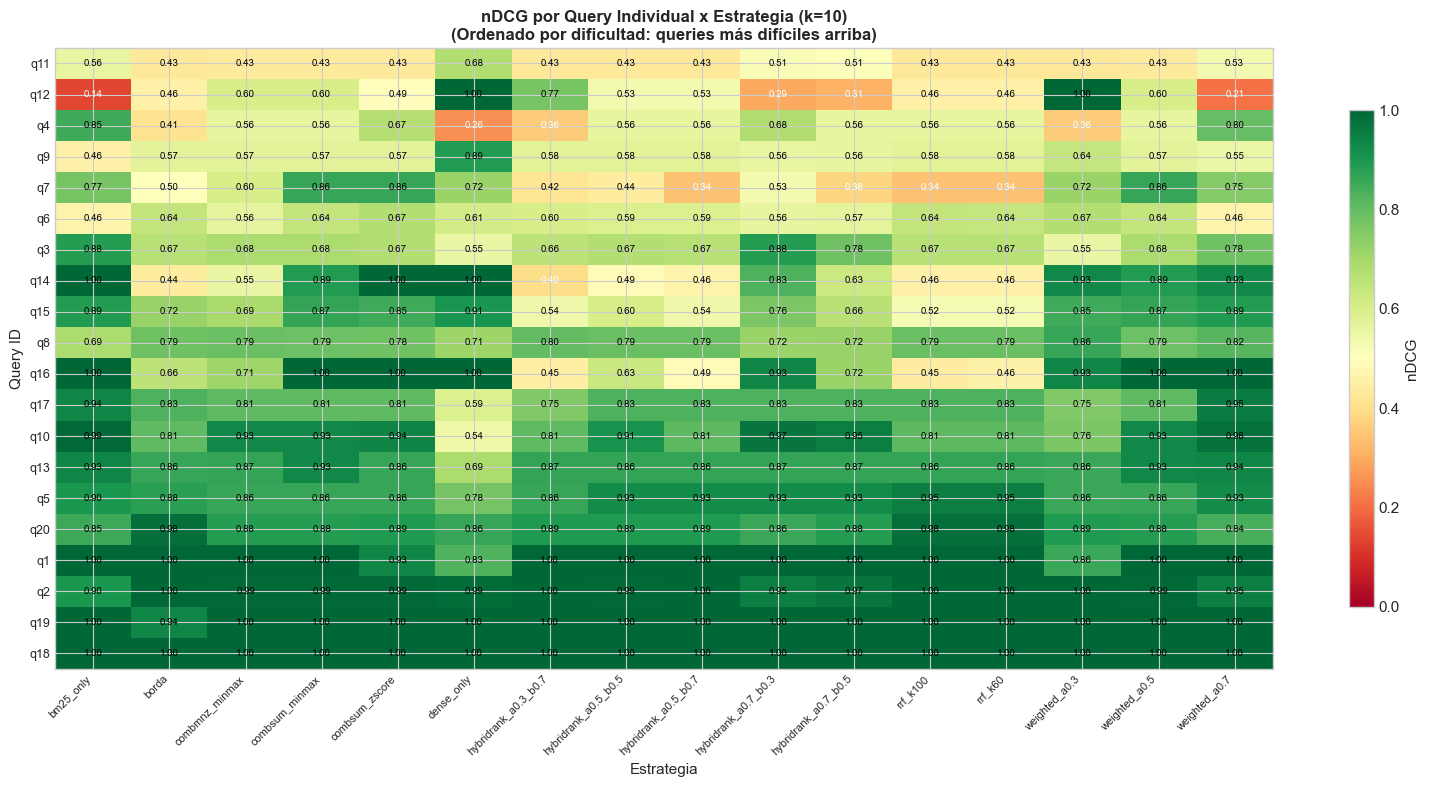

In [11]:
# --- 9a. Heatmap: nDCG por query x estrategia (k=10) ---
df_k10 = df[df['top_k'] == 10].copy()

query_strategy_ndcg = df_k10.pivot_table(
    values='ndcg', index='query_id', columns='strategy', aggfunc='mean'
).round(3)

# Ordenar queries por dificultad (promedio nDCG más bajo = más difícil)
query_strategy_ndcg['_avg'] = query_strategy_ndcg.mean(axis=1)
query_strategy_ndcg = query_strategy_ndcg.sort_values('_avg')
query_strategy_ndcg = query_strategy_ndcg.drop(columns='_avg')

fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(query_strategy_ndcg.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(query_strategy_ndcg.columns)))
ax.set_xticklabels(query_strategy_ndcg.columns, fontsize=8, rotation=45, ha='right')
ax.set_yticks(range(len(query_strategy_ndcg.index)))
ax.set_yticklabels(query_strategy_ndcg.index, fontsize=9)

for i in range(query_strategy_ndcg.shape[0]):
    for j in range(query_strategy_ndcg.shape[1]):
        val = query_strategy_ndcg.values[i, j]
        color = 'white' if val < 0.4 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color=color)

plt.colorbar(im, ax=ax, shrink=0.8, label='nDCG')
ax.set_title('nDCG por Query Individual x Estrategia (k=10)\n(Ordenado por dificultad: queries más difíciles arriba)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Estrategia')
ax.set_ylabel('Query ID')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'query_individual_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# --- 9b. Diagnóstico: queries problemáticas y resumen por query ---
df_k10 = df[df['top_k'] == 10].copy()

# Tabla resumen por query: promedio de todas las estrategias + mejor/peor
query_summary = df_k10.groupby(['query_id', 'query_type']).agg(
    ndcg_mean=('ndcg', 'mean'),
    ndcg_max=('ndcg', 'max'),
    ndcg_min=('ndcg', 'min'),
    recall_mean=('recall', 'mean'),
    mrr_mean=('mrr', 'mean'),
    ndcg_std=('ndcg', 'std'),
).round(4)

# Mejor estrategia por query
best_strategy_per_query = df_k10.loc[df_k10.groupby('query_id')['ndcg'].idxmax()][['query_id', 'strategy', 'ndcg']]
best_strategy_per_query = best_strategy_per_query.set_index('query_id').rename(columns={'strategy': 'mejor_estrategia', 'ndcg': 'mejor_ndcg'})

query_summary = query_summary.join(best_strategy_per_query, on='query_id')
query_summary = query_summary.sort_values('ndcg_mean')

print('Resumen por Query Individual (k=10)')
print('Ordenado por dificultad (ndcg_mean ascendente)\n')
display(query_summary.style.background_gradient(
    subset=['ndcg_mean', 'recall_mean', 'mrr_mean'], cmap='RdYlGn', vmin=0, vmax=1
))

# Clasificar queries por dificultad
easy = query_summary[query_summary['ndcg_mean'] >= 0.8]
medium = query_summary[(query_summary['ndcg_mean'] >= 0.5) & (query_summary['ndcg_mean'] < 0.8)]
hard = query_summary[query_summary['ndcg_mean'] < 0.5]

print(f'\n{"="*60}')
print(f'  Clasificación de Queries por Dificultad')
print(f'{"="*60}')
print(f'  Fáciles (nDCG >= 0.8): {len(easy)} queries')
print(f'  Medias  (0.5 <= nDCG < 0.8): {len(medium)} queries')
print(f'  Difíciles (nDCG < 0.5): {len(hard)} queries')

if len(hard) > 0:
    print(f'\n  Queries difíciles (potencial de mejora):')
    for idx in hard.index:
        qid = idx[0] if isinstance(idx, tuple) else idx
        row = hard.loc[idx]
        print(f'    - {qid} ({idx[1] if isinstance(idx, tuple) else ""}): '
              f'nDCG={row["ndcg_mean"]:.3f}, recall={row["recall_mean"]:.3f}, '
              f'mejor={row["mejor_estrategia"]}')

# Queries con alta varianza (sensibles a la estrategia elegida)
high_var = query_summary[query_summary['ndcg_std'] > 0.1].sort_values('ndcg_std', ascending=False)
if len(high_var) > 0:
    print(f'\n  Queries sensibles a la estrategia (std > 0.1):')
    for idx in high_var.index:
        qid = idx[0] if isinstance(idx, tuple) else idx
        row = high_var.loc[idx]
        print(f'    - {qid}: std={row["ndcg_std"]:.3f}, rango=[{row["ndcg_min"]:.3f}, {row["ndcg_max"]:.3f}]')

Resumen por Query Individual (k=10)
Ordenado por dificultad (ndcg_mean ascendente)



,,ndcg_mean,ndcg_max,ndcg_min,recall_mean,mrr_mean,ndcg_std,mejor_estrategia,mejor_ndcg
query_id,query_type,,,,,,,,
q11,compleja_hibrida,0.469400,0.677700,0.426500,0.443800,1.000000,0.070600,dense_only,0.677728
q12,compleja_hibrida,0.528400,1.000000,0.139600,0.489600,0.504300,0.244000,dense_only,1.000000
q4,referencia_exacta,0.553800,0.848600,0.256600,0.593800,0.833300,0.154100,bm25_only,0.848583
q9,compleja_hibrida,0.587000,0.890000,0.454800,0.618800,0.531200,0.088300,dense_only,0.889954
q7,semantica,0.589400,0.861100,0.342100,0.412500,0.781200,0.200900,combsum_minmax,0.861138
q6,semantica,0.598100,0.672500,0.464400,0.553600,1.000000,0.063100,combsum_zscore,0.672456
q3,referencia_exacta,0.697600,0.884500,0.553100,0.650000,1.000000,0.094300,bm25_only,0.884488
q14,ambigua,0.709200,1.000000,0.397200,0.359400,0.781200,0.241300,bm25_only,1.000000
q15,ambigua,0.730300,0.905200,0.522500,0.368100,1.000000,0.148500,dense_only,0.905212



  Clasificación de Queries por Dificultad
  Fáciles (nDCG >= 0.8): 9 queries
  Medias  (0.5 <= nDCG < 0.8): 10 queries
  Difíciles (nDCG < 0.5): 1 queries

  Queries difíciles (potencial de mejora):
    - q11 (compleja_hibrida): nDCG=0.469, recall=0.444, mejor=dense_only

  Queries sensibles a la estrategia (std > 0.1):
    - q12: std=0.244, rango=[0.140, 1.000]
    - q14: std=0.241, rango=[0.397, 1.000]
    - q16: std=0.230, rango=[0.445, 1.000]
    - q7: std=0.201, rango=[0.342, 0.861]
    - q4: std=0.154, rango=[0.257, 0.849]
    - q15: std=0.148, rango=[0.522, 0.905]
    - q10: std=0.116, rango=[0.541, 0.993]


## 10. Variabilidad por Estrategia (k=10)

Con 20 queries, diferencias pequeñas pueden ser ruido.
Esta tabla muestra mean ± std para cada métrica, lo cual permite
evaluar si las diferencias entre estrategias son significativas.

Rendimiento por estrategia: mean ± std (k=10, n=20 queries)
Estrategias con std alta tienen rendimiento inconsistente



,recall,precision,f1,mrr,map,ndcg
strategy,,,,,,
weighted_a0.7,0.7090 ± 0.2465,0.6400 ± 0.2722,0.6139 ± 0.1876,0.9321 ± 0.2167,0.5898 ± 0.2583,0.8152 ± 0.2171
combsum_minmax,0.6708 ± 0.2017,0.6300 ± 0.2793,0.5954 ± 0.1871,0.9500 ± 0.1539,0.5916 ± 0.2219,0.8151 ± 0.1741
weighted_a0.5,0.6708 ± 0.2017,0.6300 ± 0.2793,0.5954 ± 0.1871,0.9500 ± 0.1539,0.5916 ± 0.2219,0.8151 ± 0.1741
combsum_zscore,0.6766 ± 0.1908,0.6300 ± 0.2697,0.5964 ± 0.1657,0.9417 ± 0.1816,0.5872 ± 0.2169,0.8148 ± 0.1750
bm25_only,0.7072 ± 0.2698,0.6300 ± 0.2755,0.6067 ± 0.1939,0.9321 ± 0.2167,0.5887 ± 0.2648,0.8107 ± 0.2355
weighted_a0.3,0.6591 ± 0.1980,0.6250 ± 0.2826,0.5888 ± 0.1945,0.9167 ± 0.2059,0.5749 ± 0.2243,0.7965 ± 0.1868
hybridrank_a0.7_b0.3,0.6721 ± 0.2464,0.5950 ± 0.2395,0.5773 ± 0.1802,0.9350 ± 0.2059,0.5585 ± 0.2614,0.7830 ± 0.2012
dense_only,0.6551 ± 0.1805,0.6350 ± 0.3014,0.5917 ± 0.1971,0.8833 ± 0.2484,0.5470 ± 0.2193,0.7798 ± 0.2047
combmnz_minmax,0.6352 ± 0.2300,0.5700 ± 0.2364,0.5513 ± 0.1849,0.9250 ± 0.1832,0.5387 ± 0.2606,0.7552 ± 0.1808


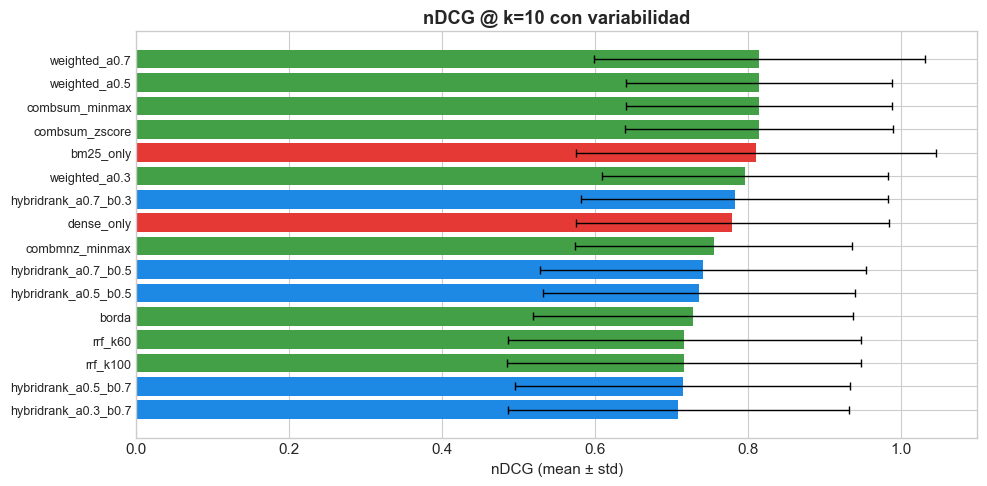

In [13]:
# Mean ± std por estrategia (k=10)
df_k10 = df[df['top_k'] == 10].copy()

stats = df_k10.groupby('strategy')[METRIC_COLS].agg(['mean', 'std']).round(4)
stats.columns = [f'{m}_{s}' for m, s in stats.columns]

# Crear tabla legible con formato "mean ± std"
display_df = pd.DataFrame(index=stats.index)
for metric in METRIC_COLS:
    display_df[metric] = stats.apply(
        lambda row: f"{row[f'{metric}_mean']:.4f} ± {row[f'{metric}_std']:.4f}", axis=1
    )

display_df = display_df.loc[stats.sort_values('ndcg_mean', ascending=False).index]

print('Rendimiento por estrategia: mean ± std (k=10, n=20 queries)')
print('Estrategias con std alta tienen rendimiento inconsistente\n')
display(display_df)

# Visualización rápida: barras con error bars para nDCG
fig, ax = plt.subplots(figsize=(10, 5))
means = df_k10.groupby('strategy')['ndcg'].mean().sort_values()
stds = df_k10.groupby('strategy')['ndcg'].std().loc[means.index]

colors = []
for name in means.index:
    if name in BASELINES:
        colors.append('#E53935')
    elif 'hybridrank' in name:
        colors.append('#1E88E5')
    else:
        colors.append('#43A047')

ax.barh(range(len(means)), means.values, xerr=stds.values, color=colors,
        capsize=3, error_kw={'linewidth': 1})
ax.set_yticks(range(len(means)))
ax.set_yticklabels(means.index, fontsize=9)
ax.set_xlabel('nDCG (mean ± std)')
ax.set_title('nDCG @ k=10 con variabilidad', fontweight='bold')
ax.set_xlim(0, 1.1)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'ndcg_variability.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Conteo de Ganadores por Familia (k=10)

Cuenta cuántas queries "gana" cada familia de estrategias (mayor nDCG).
Ayuda narrativamente a ver qué enfoque domina y dónde hay oportunidad.

In [14]:
# Conteo de ganadores por familia y por estrategia individual (k=10)
df_k10 = df[df['top_k'] == 10].copy()

def get_family(s):
    if s in BASELINES:
        return 'Baseline'
    elif 'hybridrank' in s:
        return 'HybridRank'
    elif 'weighted' in s:
        return 'Weighted'
    else:
        return 'Fusión Clásica'

# Mejor estrategia por query (nDCG)
best_per_query = df_k10.loc[df_k10.groupby('query_id')['ndcg'].idxmax()].copy()
best_per_query['familia'] = best_per_query['strategy'].map(get_family)

# Conteo por familia
family_wins = best_per_query['familia'].value_counts()
print('Queries ganadas por FAMILIA (mayor nDCG, k=10):')
print('=' * 40)
for family, count in family_wins.items():
    pct = count / len(best_per_query) * 100
    bar = '█' * int(pct / 5)
    print(f'  {family:<20} {count:>2} queries ({pct:.0f}%) {bar}')

# Conteo por estrategia individual
print(f'\nQueries ganadas por ESTRATEGIA individual:')
print('-' * 40)
strategy_wins = best_per_query['strategy'].value_counts()
for strategy, count in strategy_wins.items():
    print(f'  {strategy:<30} {count:>2} queries')

# Desglose: qué familia gana en cada query_type
print(f'\nGanadores por query_type:')
print('-' * 40)
for qt in sorted(best_per_query['query_type'].unique()):
    qt_winners = best_per_query[best_per_query['query_type'] == qt]['familia'].value_counts()
    winners_str = ', '.join([f'{f}: {c}' for f, c in qt_winners.items()])
    print(f'  {qt}: {winners_str}')

Queries ganadas por FAMILIA (mayor nDCG, k=10):
  Baseline             12 queries (60%) ████████████
  Fusión Clásica        5 queries (25%) █████
  Weighted              3 queries (15%) ███

Queries ganadas por ESTRATEGIA individual:
----------------------------------------
  bm25_only                       8 queries
  dense_only                      4 queries
  rrf_k60                         3 queries
  weighted_a0.7                   2 queries
  combsum_zscore                  1 queries
  combsum_minmax                  1 queries
  weighted_a0.3                   1 queries

Ganadores por query_type:
----------------------------------------
  ambigua: Baseline: 2, Weighted: 1
  compleja_hibrida: Baseline: 4
  multi_hop: Baseline: 2, Weighted: 1, Fusión Clásica: 1
  referencia_exacta: Baseline: 3, Fusión Clásica: 1
  semantica: Fusión Clásica: 3, Weighted: 1
  temporal_historica: Baseline: 1


In [15]:
# 11b. Mejor estrategia por tipo de consulta con métricas detalladas y Objective
df_k10 = df[df['top_k'] == 10].copy()

# Calcular Objective por fila
df_k10['objective'] = (
    0.4 * df_k10['ndcg'] +
    0.3 * df_k10['recall'] +
    0.2 * df_k10['map'] +
    0.1 * df_k10['f1']
)

# Para cada query_type, encontrar la estrategia con mayor Objective promedio
best_by_type = []
for qt in sorted(df_k10['query_type'].unique()):
    qt_data = df_k10[df_k10['query_type'] == qt]
    qt_means = qt_data.groupby('strategy')[['recall', 'precision', 'f1', 'mrr', 'map', 'ndcg', 'objective']].mean()
    best_strategy = qt_means['objective'].idxmax()
    row = qt_means.loc[best_strategy].to_dict()
    row['query_type'] = qt
    row['best_strategy'] = best_strategy
    row['n_queries'] = qt_data['query_id'].nunique()
    best_by_type.append(row)

best_by_type_df = pd.DataFrame(best_by_type)
best_by_type_df = best_by_type_df[['query_type', 'n_queries', 'best_strategy', 
                                     'recall', 'ndcg', 'mrr', 'map', 'f1', 'precision', 'objective']]
best_by_type_df = best_by_type_df.round(4)

print('Mejor estrategia por tipo de consulta (k=10, según Objective)')
print('Objective = 0.4*nDCG + 0.3*Recall + 0.2*MAP + 0.1*F1')
print('=' * 75)

display(best_by_type_df.set_index('query_type').style.background_gradient(
    subset=['recall', 'ndcg', 'mrr', 'map', 'objective'],
    cmap='RdYlGn', vmin=0.4, vmax=1.0
).format(precision=4))

# Resumen para LaTeX
print('\n\nResumen para tabla LaTeX:')
print('-' * 75)
print(f'{"Tipo de consulta":<25} {"n":>3} {"Ganador":<30} {"Objective":>9} {"nDCG":>7} {"Recall":>7} {"MRR":>7}')
print('-' * 75)
for _, row in best_by_type_df.iterrows():
    print(f'{row["query_type"]:<25} {int(row["n_queries"]):>3} {row["best_strategy"]:<30} '
          f'{row["objective"]:>9.4f} {row["ndcg"]:>7.4f} {row["recall"]:>7.4f} {row["mrr"]:>7.4f}')


Mejor estrategia por tipo de consulta (k=10, según Objective)
Objective = 0.4*nDCG + 0.3*Recall + 0.2*MAP + 0.1*F1


,n_queries,best_strategy,recall,ndcg,mrr,map,f1,precision,objective
query_type,,,,,,,,,
ambigua,3,bm25_only,0.6333,0.9412,1.0000,0.6097,0.7365,0.9333,0.7621
compleja_hibrida,4,dense_only,0.7333,0.7771,1.0000,0.6082,0.7210,0.7250,0.7246
multi_hop,4,bm25_only,0.8750,0.9474,1.0000,0.7519,0.5425,0.5250,0.8461
referencia_exacta,4,bm25_only,0.9423,0.9083,1.0000,0.7390,0.7144,0.6250,0.8653
semantica,4,combsum_zscore,0.6655,0.7940,1.0000,0.5525,0.6660,0.7000,0.6943
temporal_historica,1,bm25_only,0.5000,1.0000,1.0000,0.5000,0.6667,1.0000,0.7167




Resumen para tabla LaTeX:
---------------------------------------------------------------------------
Tipo de consulta            n Ganador                        Objective    nDCG  Recall     MRR
---------------------------------------------------------------------------
ambigua                     3 bm25_only                         0.7621  0.9412  0.6333  1.0000
compleja_hibrida            4 dense_only                        0.7246  0.7771  0.7333  1.0000
multi_hop                   4 bm25_only                         0.8461  0.9474  0.8750  1.0000
referencia_exacta           4 bm25_only                         0.8653  0.9083  0.9423  1.0000
semantica                   4 combsum_zscore                    0.6943  0.7940  0.6655  1.0000
temporal_historica          1 bm25_only                         0.7167  1.0000  0.5000  1.0000


## 12. Overlap BM25 vs Dense

Mide la complementariedad de los dos recuperadores base.
`overlap@k = |top_k_bm25 ∩ top_k_dense| / k`

- Overlap bajo → los recuperadores aportan documentos distintos → la fusión tiene más valor.
- Overlap alto → ambos coinciden → la fusión es menos necesaria.

**Prerequisito**: re-ejecutar `experiments/evaluate_fusion_strategies.py` para generar `retriever_overlap.csv`.

Overlap BM25 ∩ Dense / k  (0=complementarios, 1=idénticos)


top_k,5,10,20,promedio
query_type,,,,
ambigua,0.200000,0.167000,0.233000,0.200000
compleja_híbrida,0.250000,0.375000,0.550000,0.392000
multi_hop,0.300000,0.275000,0.312000,0.296000
referencia_exacta,0.400000,0.450000,0.325000,0.392000
semántica,0.150000,0.225000,0.300000,0.225000
temporal_histórica,0.000000,0.000000,0.050000,0.017000
GLOBAL,0.250000,0.290000,0.335000,0.292000



Desglose de documentos únicos (k=10, promedio por query):
  BM25 únicos: 7.1 / 10
  Dense únicos: 7.1 / 10
  Compartidos:  2.9 / 10


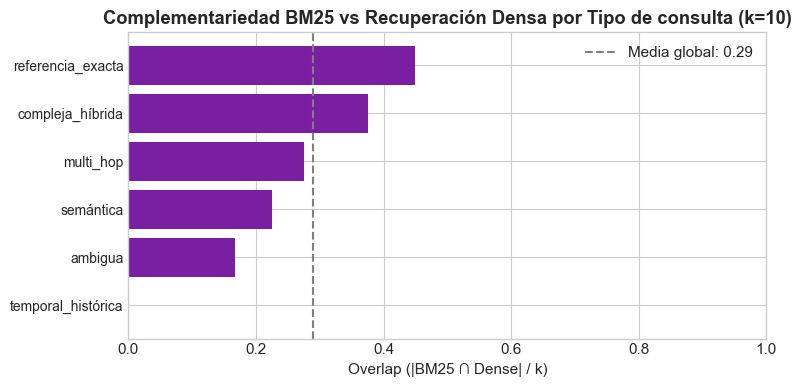

In [16]:
# Overlap BM25 vs Dense
overlap_path = RESULTS_DIR / 'retriever_overlap.csv'

if overlap_path.exists():
    overlap_df = pd.read_csv(overlap_path)
    
    # Resumen por query_type y k
    overlap_summary = overlap_df.pivot_table(
        values='overlap', index='query_type', columns='top_k', aggfunc='mean'
    ).round(3)
    overlap_summary['promedio'] = overlap_summary.mean(axis=1)
    overlap_summary.loc['GLOBAL'] = overlap_df.groupby('top_k')['overlap'].mean().values.tolist() + [overlap_df['overlap'].mean()]
    overlap_summary = overlap_summary.round(3)
    
    print('Overlap BM25 ∩ Dense / k  (0=complementarios, 1=idénticos)')
    print('=' * 50)
    display(overlap_summary.style.background_gradient(cmap='RdYlGn_r', vmin=0, vmax=1))
    
    # Documentos únicos por recuperador (k=10)
    ov_k10 = overlap_df[overlap_df['top_k'] == 10]
    print(f'\nDesglose de documentos únicos (k=10, promedio por query):')
    print(f'  BM25 únicos: {ov_k10["bm25_unique"].mean():.1f} / 10')
    print(f'  Dense únicos: {ov_k10["dense_unique"].mean():.1f} / 10')
    print(f'  Compartidos:  {ov_k10["shared"].mean():.1f} / 10')
    
    # Gráfico: overlap por query_type (k=10)
    fig, ax = plt.subplots(figsize=(8, 4))
    ov_by_type = ov_k10.groupby('query_type')['overlap'].mean().sort_values()
    ax.barh(range(len(ov_by_type)), ov_by_type.values, color='#7B1FA2')
    ax.set_yticks(range(len(ov_by_type)))
    ax.set_yticklabels(ov_by_type.index, fontsize=10)
    ax.set_xlabel('Overlap (|BM25 ∩ Dense| / k)')
    ax.set_title('Complementariedad BM25 vs Recuperación Densa por Tipo de consulta (k=10)', fontweight='bold')
    ax.set_xlim(0, 1)
    ax.axvline(ov_k10['overlap'].mean(), color='gray', linestyle='--', label=f'Media global: {ov_k10["overlap"].mean():.2f}')
    ax.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'overlap_by_query_type.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('[!] No se encontró retriever_overlap.csv')
    print('    Ejecuta: .venv/Scripts/python.exe experiments/evaluate_fusion_strategies.py')

## 13. Oracle por Query (Upper Bound para Fusión Adaptativa)

El **oracle** selecciona, para cada query, la estrategia que obtiene el mejor nDCG.
Representa el techo alcanzable si tuviéramos un clasificador perfecto que eligiera
la mejor estrategia por query.

Si `oracle >> weighted_a0.7`, hay espacio para mejorar con fusión adaptativa (Phase 2).

In [17]:
# Oracle: mejor estrategia posible por query (k=10)
df_k10 = df[df['top_k'] == 10].copy()
REFERENCE = 'weighted_a0.7'

# Oracle = para cada query, tomar la fila con mayor nDCG
oracle = df_k10.loc[df_k10.groupby('query_id')['ndcg'].idxmax()].copy()
oracle_means = oracle[METRIC_COLS].mean()

# Referencia
ref_means = df_k10[df_k10['strategy'] == REFERENCE][METRIC_COLS].mean()

# Mejor estrategia fija (global)
all_means = df_k10.groupby('strategy')[METRIC_COLS].mean()
best_fixed = all_means['ndcg'].idxmax()
best_fixed_means = all_means.loc[best_fixed]

# Tabla comparativa
comparison = pd.DataFrame({
    'Oracle (por query)': oracle_means,
    f'Mejor fija ({best_fixed})': best_fixed_means,
    f'{REFERENCE}': ref_means,
}).round(4).T

print('Comparación: Oracle vs Mejor Estrategia Fija vs Referencia (k=10)')
print('=' * 65)
display(comparison.style.background_gradient(cmap='RdYlGn', axis=None, vmin=0, vmax=1))

# Gap cuantificado
gap_vs_ref = oracle_means - ref_means
gap_vs_best = oracle_means - best_fixed_means

print(f'\n{"─"*65}')
print(f'  Gap Oracle vs {REFERENCE}:')
for m in ['recall', 'ndcg', 'mrr']:
    print(f'    {m.upper():>8}: +{gap_vs_ref[m]:.4f} ({gap_vs_ref[m]/ref_means[m]*100:.1f}% relativo)')

print(f'\n  Gap Oracle vs mejor fija ({best_fixed}):')
for m in ['recall', 'ndcg', 'mrr']:
    print(f'    {m.upper():>8}: +{gap_vs_best[m]:.4f} ({gap_vs_best[m]/best_fixed_means[m]*100:.1f}% relativo)')

print(f'\n{"─"*65}')
if gap_vs_ref['ndcg'] > 0.03:
    print(f'  ✓ El oracle supera a {REFERENCE} en +{gap_vs_ref["ndcg"]:.4f} nDCG.')
    print(f'    → Hay espacio significativo para fusión adaptativa (Phase 2).')
else:
    print(f'  ≈ El gap es pequeño ({gap_vs_ref["ndcg"]:.4f} nDCG).')
    print(f'    → El beneficio de fusión adaptativa sería marginal.')

# Desglose oracle por query_type
print(f'\n\nOracle por query_type vs {REFERENCE}:')
print('-' * 50)
oracle_by_type = oracle.groupby('query_type')[METRIC_COLS].mean()
ref_by_type = df_k10[df_k10['strategy'] == REFERENCE].groupby('query_type')[METRIC_COLS].mean()
gap_by_type = (oracle_by_type - ref_by_type).round(4)

for qt in sorted(gap_by_type.index):
    ndcg_gap = gap_by_type.loc[qt, 'ndcg']
    print(f'  {qt:<25} gap nDCG: +{ndcg_gap:.4f}')

Comparación: Oracle vs Mejor Estrategia Fija vs Referencia (k=10)


,recall,precision,f1,mrr,map,ndcg
Oracle (por query),0.798300,0.730000,0.701200,1.000000,0.718000,0.920900
Mejor fija (weighted_a0.7),0.709000,0.640000,0.613900,0.932100,0.589800,0.815200
weighted_a0.7,0.709000,0.640000,0.613900,0.932100,0.589800,0.815200



─────────────────────────────────────────────────────────────────
  Gap Oracle vs weighted_a0.7:
      RECALL: +0.0893 (12.6% relativo)
        NDCG: +0.1057 (13.0% relativo)
         MRR: +0.0679 (7.3% relativo)

  Gap Oracle vs mejor fija (weighted_a0.7):
      RECALL: +0.0893 (12.6% relativo)
        NDCG: +0.1057 (13.0% relativo)
         MRR: +0.0679 (7.3% relativo)

─────────────────────────────────────────────────────────────────
  ✓ El oracle supera a weighted_a0.7 en +0.1057 nDCG.
    → Hay espacio significativo para fusión adaptativa (Phase 2).


Oracle por query_type vs weighted_a0.7:
--------------------------------------------------
  ambigua                   gap nDCG: +0.0282
  compleja_hibrida          gap nDCG: +0.3239
  multi_hop                 gap nDCG: +0.0367
  referencia_exacta         gap nDCG: +0.0505
  semantica                 gap nDCG: +0.0961
  temporal_historica        gap nDCG: +0.0000


## 14. Cierre Formal: Fase 2 - Optimizacion de Parametros

Esta seccion presenta los resultados finales de la fase de optimizacion.

**Distincion metodologica importante:**

- **In-sample**: Metricas evaluadas con configuracion FIJA sobre las 20 queries completas. Representa el rendimiento maximo observado, pero puede tener sesgo de sobreajuste porque los parametros se seleccionaron usando estas mismas queries.
- **LOO-CV (Leave-One-Out)**: Para cada query, los parametros se optimizan en las otras 19 y se evalua en la query excluida. Ofrece una estimacion mas conservadora y no sesgada del rendimiento de generalizacion.

**Configuracion congelada de HybridRank:**

```
HybridRankFusion(alpha=0.7, beta=0.2, k=10, normalizer="minmax", rrf_normalizer="minmax")
candidate_k = 50
```

**Configuracion congelada de Weighted optimizado:**

```
WeightedScoreFusion(alpha=0.7, normalizer="minmax")
candidate_k = 20
```

In [18]:
# 14a. Tabla comparativa in-sample final (todas las estrategias, config fija, 20 queries)
insample_df = pd.read_csv(RESULTS_DIR / 'final_phase2_insample.csv')

print('Evaluacion In-Sample: Todas las estrategias con config fija (k=10)')
print('=' * 70)
print(f'Total estrategias: {len(insample_df)}')
print(f'Metrica objetivo: 0.4*nDCG + 0.3*Recall + 0.2*MAP + 0.1*F1\n')

display(insample_df.style.background_gradient(
    subset=['recall', 'precision', 'f1', 'mrr', 'map', 'ndcg', 'objective'],
    cmap='RdYlGn', vmin=0.4, vmax=0.9
))

Evaluacion In-Sample: Todas las estrategias con config fija (k=10)
Total estrategias: 12
Metrica objetivo: 0.4*nDCG + 0.3*Recall + 0.2*MAP + 0.1*F1



,strategy,strategy_family,config,candidate_k,recall,precision,f1,mrr,map,ndcg,objective
0,weighted_optimized,weighted,"weighted(alpha=0.7, normalizer=minmax)",20,0.733600,0.660000,0.635000,0.935000,0.601000,0.829500,0.735600
1,hybridrank_optimized,hybridrank,"hybridrank(alpha=0.7, beta=0.2, k=10, normalizer=minmax, rrf_normalizer=minmax)",50,0.730300,0.655000,0.631000,0.937500,0.602800,0.831000,0.735100
2,weighted_a0.7,weighted,weighted(alpha=0.7),50,0.709000,0.640000,0.613900,0.932100,0.590300,0.815500,0.718300
3,bm25_only,baseline,bm25_only,50,0.707200,0.630000,0.606700,0.932100,0.588700,0.810700,0.714900
4,combsum_zscore,classic,combsum(normalizer=zscore),50,0.676600,0.630000,0.596400,0.941700,0.587200,0.814800,0.706000
5,combsum_minmax,classic,combsum(normalizer=minmax),50,0.670800,0.630000,0.595400,0.925000,0.589900,0.811000,0.703200
6,hybridrank_a0.7_b0.3,hybridrank,"hybridrank(alpha=0.7, beta=0.3)",50,0.672100,0.595000,0.577300,0.935000,0.558500,0.783000,0.684300
7,dense_only,baseline,dense_only,50,0.655100,0.635000,0.591700,0.883300,0.547000,0.779800,0.677000
8,combmnz_minmax,classic,combmnz(normalizer=minmax),50,0.635200,0.570000,0.551300,0.925000,0.538200,0.754400,0.655100
9,borda,classic,borda(),50,0.627200,0.560000,0.542400,0.875000,0.523900,0.731400,0.639700


In [19]:
# 14b. Resumen LOO-CV (estimacion no sesgada de generalizacion)
loocv_df = pd.read_csv(RESULTS_DIR / 'final_phase2_loocv.csv')

print('Leave-One-Out Cross Validation: Estimacion No Sesgada')
print('=' * 60)
print('Para cada query, se optimizan params en las otras 19 y se evalua en la excluida.\n')
display(loocv_df.style.format(precision=4))

print(f'\nOverfitting gap (train - test):')
for _, row in loocv_df.iterrows():
    print(f'  {row["strategy"]}: {row["overfitting_gap"]:.4f}')


Leave-One-Out Cross Validation: Estimacion No Sesgada
Para cada query, se optimizan params en las otras 19 y se evalua en la excluida.



,strategy,mean_train_objective,mean_test_objective,std_test_objective,overfitting_gap,mean_test_recall,mean_test_precision,mean_test_f1,mean_test_mrr,mean_test_map,mean_test_ndcg
0,weighted_optimized,0.7286,0.6816,0.2014,0.0470,0.6631,0.6050,0.5794,0.9321,0.5569,0.7832
1,hybridrank_optimized,0.7360,0.7098,0.2049,0.0263,0.6965,0.6300,0.6040,0.9333,0.5847,0.8087



Overfitting gap (train - test):
  weighted_optimized: 0.0470
  hybridrank_optimized: 0.0263


Comparacion Pareada: HybridRank vs Weighted (held-out LOO-CV)
  HybridRank wins: 10
  Weighted wins:   3
  Ties:            7
  Mean difference: 0.0282 (positivo = HybridRank mejor)



,query_id,query_type,objective_weighted,objective_hybridrank,difference,winner
0,q1,referencia_exacta,0.871600,0.871600,0.000000,tie
1,q2,referencia_exacta,0.929500,0.929500,0.000000,tie
2,q3,referencia_exacta,0.726300,0.589600,-0.136700,weighted
3,q4,referencia_exacta,0.477000,0.792800,0.315800,hybridrank
4,q5,semantica,0.920300,0.920300,0.000000,tie
5,q6,semantica,0.497800,0.409800,-0.088000,weighted
6,q7,semantica,0.516200,0.601900,0.085700,hybridrank
7,q8,semantica,0.595000,0.690200,0.095200,hybridrank
8,q9,compleja_hibrida,0.533800,0.533800,0.000000,tie
9,q10,compleja_hibrida,0.924100,0.945700,0.021600,hybridrank


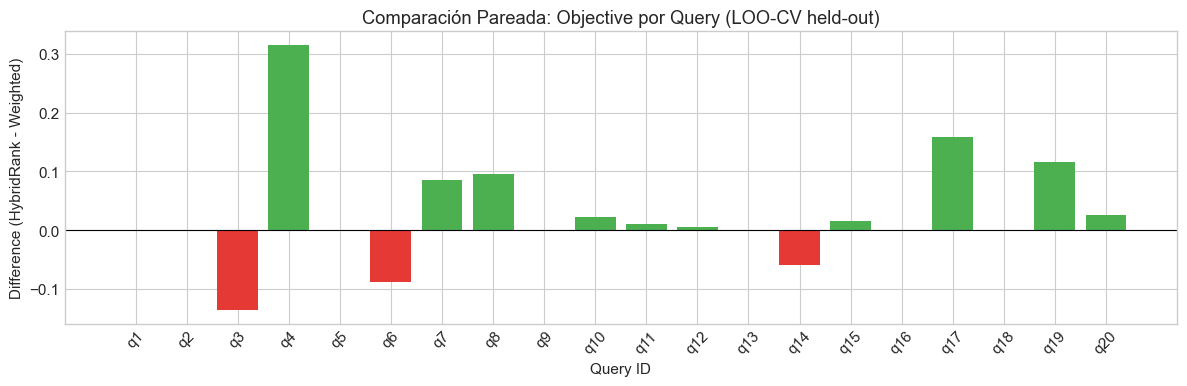

In [20]:
# 14c. Comparacion pareada query por query (datos held-out)
paired_df = pd.read_csv(RESULTS_DIR / 'paired_hybridrank_vs_weighted.csv')

print('Comparacion Pareada: HybridRank vs Weighted (held-out LOO-CV)')
print('=' * 65)
print(f'  HybridRank wins: {(paired_df["winner"]=="hybridrank").sum()}')
print(f'  Weighted wins:   {(paired_df["winner"]=="weighted").sum()}')
print(f'  Ties:            {(paired_df["winner"]=="tie").sum()}')
print(f'  Mean difference: {paired_df["difference"].mean():.4f} (positivo = HybridRank mejor)\n')

display(paired_df.style.map(
    lambda v: 'color: green; font-weight: bold' if v == 'hybridrank'
    else ('color: red' if v == 'weighted' else ''),
    subset=['winner']
))

# Barras por query
fig, ax = plt.subplots(figsize=(12, 4))
colors = ['#4CAF50' if w == 'hybridrank' else '#E53935' if w == 'weighted' else '#BDBDBD'
          for w in paired_df['winner']]
ax.bar(paired_df['query_id'], paired_df['difference'], color=colors, edgecolor='none')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Query ID')
ax.set_ylabel('Difference (HybridRank - Weighted)')
ax.set_title('Comparación Pareada: Objective por Query (LOO-CV held-out)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


In [21]:
# 14d. Tests estadisticos
import json as _json
stats = _json.load(open(RESULTS_DIR / 'paired_statistical_tests.json', 'r', encoding='utf-8'))

print('Tests Estadisticos: HybridRank vs Weighted')
print('=' * 55)

print(f'\n  Sign Test:')
print(f'    HybridRank wins: {stats["sign_test"]["hybridrank_wins"]}')
print(f'    Weighted wins:   {stats["sign_test"]["weighted_wins"]}')
print(f'    p-value:         {stats["sign_test"]["p_value"]}')

print(f'\n  Bootstrap (10,000 muestras):')
print(f'    Mean difference: {stats["bootstrap"]["mean"]:.4f}')
print(f'    95% CI:          [{stats["bootstrap"]["ci_lower"]:.4f}, {stats["bootstrap"]["ci_upper"]:.4f}]')

print(f'\n  Wilcoxon Signed-Rank:')
print(f'    Statistic: {stats["wilcoxon"]["statistic"]}')
print(f'    p-value:   {stats["wilcoxon"]["p_value"]}')

print(f'\n  Interpretacion:')
p_sign = stats['sign_test']['p_value']
if p_sign is not None and p_sign < 0.05:
    print('    -> Diferencia SIGNIFICATIVA (p < 0.05). HybridRank es estadisticamente superior.')
else:
    print('    -> Diferencia NO significativa (p >= 0.05) con 20 queries.')
    print('    -> HybridRank muestra ventaja consistente (10 wins vs 3) pero el tamano')
    print('       de muestra es insuficiente para significancia estadistica convencional.')
    ci_lower = stats['bootstrap']['ci_lower']
    if ci_lower < 0:
        print(f'    -> Bootstrap CI incluye 0: la ventaja puede ser nula en algunos escenarios.')
    else:
        print(f'    -> Bootstrap CI no incluye 0: la ventaja es robusta bajo resampling.')


Tests Estadisticos: HybridRank vs Weighted

  Sign Test:
    HybridRank wins: 10
    Weighted wins:   3
    p-value:         0.0923

  Bootstrap (10,000 muestras):
    Mean difference: 0.0278
    95% CI:          [-0.0096, 0.0714]

  Wilcoxon Signed-Rank:
    Statistic: 25.0
    p-value:   0.1677

  Interpretacion:
    -> Diferencia NO significativa (p >= 0.05) con 20 queries.
    -> HybridRank muestra ventaja consistente (10 wins vs 3) pero el tamano
       de muestra es insuficiente para significancia estadistica convencional.
    -> Bootstrap CI incluye 0: la ventaja puede ser nula en algunos escenarios.


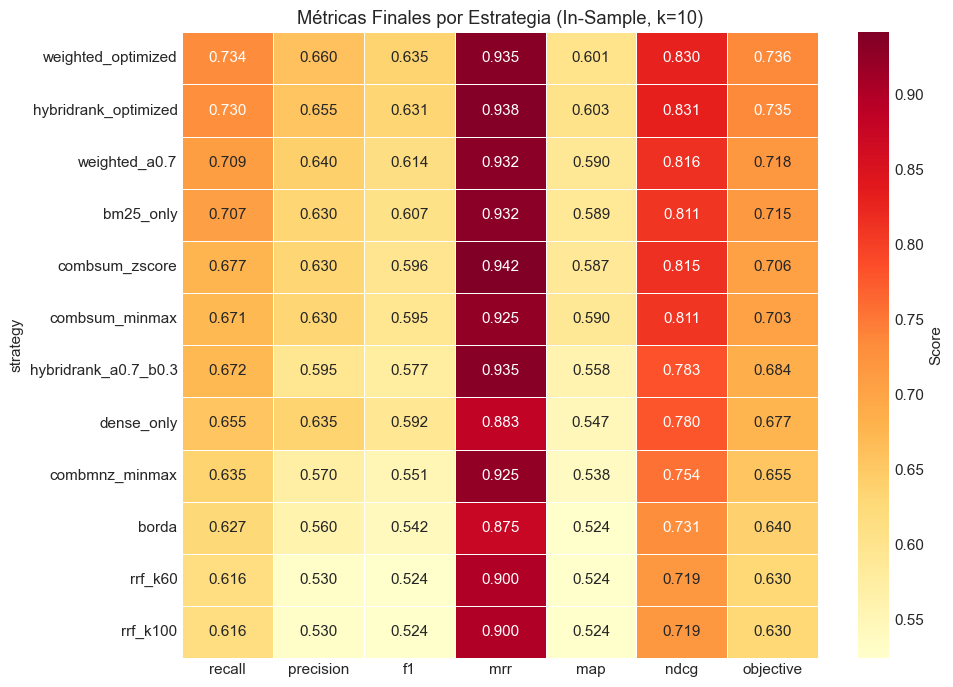

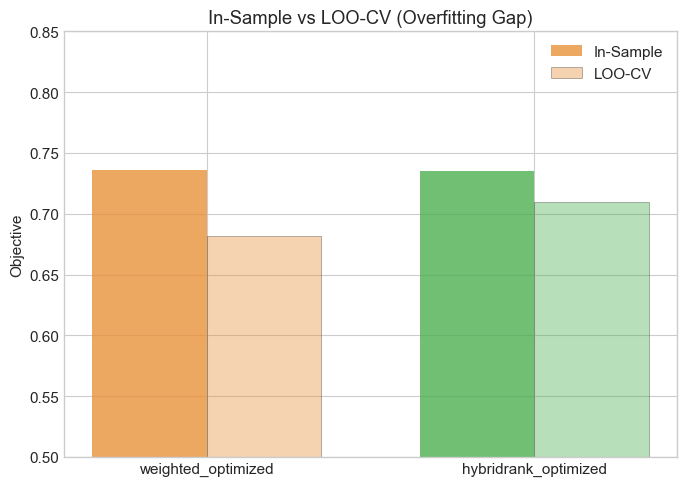

In [22]:
# 14e. Visualizaciones finales
import seaborn as sns

# Heatmap de metricas por estrategia
fig, ax = plt.subplots(figsize=(10, 7))
metric_cols = ['recall', 'precision', 'f1', 'mrr', 'map', 'ndcg', 'objective']
heatmap_data = insample_df.set_index('strategy')[metric_cols]
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Score'})
ax.set_title('Métricas Finales por Estrategia (In-Sample, k=10)')
plt.tight_layout()
plt.show()

# In-sample vs LOO-CV (overfitting gap)
fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(2)
width = 0.35
insample_vals = [
    float(insample_df[insample_df['strategy'] == 'weighted_optimized']['objective'].iloc[0]),
    float(insample_df[insample_df['strategy'] == 'hybridrank_optimized']['objective'].iloc[0]),
]
loocv_vals = list(loocv_df['mean_test_objective'].values)
ax.bar(x - width/2, insample_vals, width, label='In-Sample', color=['#E8913A', '#4CAF50'], alpha=0.8)
ax.bar(x + width/2, loocv_vals, width, label='LOO-CV', color=['#E8913A', '#4CAF50'], alpha=0.4,
       edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(['weighted_optimized', 'hybridrank_optimized'])
ax.set_ylabel('Objective')
ax.set_title('In-Sample vs LOO-CV (Overfitting Gap)')
ax.legend()
ax.set_ylim(0.5, 0.85)
plt.tight_layout()
plt.show()


## Conclusion Fase 2

### Resultados clave

1. **HybridRank supera a Weighted en generalizacion**: LOO-CV objective 0.7098 vs 0.6816 (+0.028).
2. **Overfitting gap menor**: HybridRank tiene gap de 0.026 vs 0.047 de Weighted, indicando mejor estabilidad.
3. **Comparacion pareada favorable**: HybridRank gana en 10/20 queries vs 3/20 para Weighted (7 empates).
4. **Significancia estadistica marginal**: p=0.09 (sign test). Con 20 queries el poder estadistico es limitado, pero la tendencia es clara.
5. **Bootstrap CI**: La diferencia media incluye ligeramente el 0, coherente con p>0.05.

### Configuracion congelada para produccion

```python
HybridRankFusion(
    alpha=0.7,      # BM25 pesa mas que Dense en corpus juridico
    beta=0.2,       # RRF como regularizador, no senal dominante
    k=10,           # Alta discriminacion en posiciones altas
    normalizer='minmax',
    rrf_normalizer='minmax',
)
# candidate_k = 50
```